In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True


Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
train_df = pd.read_csv("../data/processed/train_all_versions.csv")
val_df = pd.read_csv("../data/processed/val_all_versions.csv")
test_df = pd.read_csv("../data/processed/test_all_versions.csv")


print(train_df.shape)

(155551, 8)


In [31]:
binary_mapping = {
    "very_negative": 0,
    "negative": 0,
    "neutral": 0,
    "positive": 1,
    "very_positive": 1
}

train_df["label"] = train_df["sentiment"].map(binary_mapping)
val_df["label"] = val_df["sentiment"].map(binary_mapping)
test_df["label"] = test_df["sentiment"].map(binary_mapping)

train_df = train_df.dropna(subset=["text_dl", "label"])
val_df = val_df.dropna(subset=["text_dl", "label"])
test_df = test_df.dropna(subset=["text_dl", "label"])


print(train_df["label"].value_counts())


label
1    118861
0     36608
Name: count, dtype: int64


In [32]:
train_sentences = train_df["text_dl"].astype(str).values
val_sentences = val_df["text_dl"].astype(str).values
test_sentences = test_df["text_dl"].astype(str).values

train_labels = train_df["label"].values
val_labels = val_df["label"].values
test_labels = test_df["label"].values


BUILD VOCAB

In [ ]:
words = Counter()

# split sentences into words and count frequencies
for sentence in train_sentences:
    words.update(sentence.split())

min_freq = 3

vocab = [word for word, freq in words.items() if freq >= min_freq]
# used to pad shorter sentences and use _UNK when word is not in vocab
vocab = ["_PAD", "_UNK"] + vocab
# mapping word as integer as neural networks need numeric input 
word2idx = {word: idx for idx, word in enumerate(vocab)}

print("Vocab size:", len(vocab))


Vocab size: 64671


Encoding + Padding

In [34]:
def encode(sentences):
    encoded = []
    for sentence in sentences:
        tokens = sentence.split()
        encoded.append([word2idx.get(word, 1) for word in tokens])
    return encoded

train_encoded = encode(train_sentences)
val_encoded = encode(val_sentences)
test_encoded = encode(test_sentences)


In [ ]:
seq_len = 150

# we are right padding the sequences so that the model focuses more on the end of the reviews, which often contain the most important information for sentiment analysis. 
def pad_sequences(encoded):
    features = np.zeros((len(encoded), seq_len), dtype=np.int64)
    for i, review in enumerate(encoded):
        features[i, -len(review):] = np.array(review)[:seq_len]
    return features

X_train = pad_sequences(train_encoded)
X_val = pad_sequences(val_encoded)
X_test = pad_sequences(test_encoded)


In [ ]:
X_train = torch.from_numpy(X_train)
X_val = torch.from_numpy(X_val)
X_test = torch.from_numpy(X_test)

y_train = torch.from_numpy(train_labels).long()
y_val = torch.from_numpy(val_labels).long()
y_test = torch.from_numpy(test_labels).long()

batch_size = 256 # this batch size works well on my gpu

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, pin_memory=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, pin_memory=True)


Glove Embeddings

In [ ]:
#GloVe captures semantic relationships
# basically the model already learns the for ex : good is close to great and bad is close to terrible in the embedding space,
def load_glove(path):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

glove_path = "../data/glove/glove.6B.300d.txt"
glove = load_glove(glove_path)


In [ ]:
embedding_dim = 300 # because we choose glove 6b 300 d 
embedding_matrix = np.zeros((len(vocab), embedding_dim))
# we create this because without pre trained embeddings. Models must learn from sratch and it requires huge dataset and time
for word, idx in word2idx.items():
    if word in glove:
        embedding_matrix[idx] = glove[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float)


In [ ]:
class BiLSTM_Attention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, embedding_matrix):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim) # we do the transformation (basically  each word becomes 300-dim vector)
        self.embedding.weight = nn.Parameter(embedding_matrix)
        self.embedding.weight.requires_grad = False
        
        self.lstm = nn.LSTM(
            embedding_dim, # input size (300 in our case)
            hidden_dim, # 384 in our case
            num_layers=2, # stacked lstms layer 1 -> Lower features, layer 2 -> Higher level features
            batch_first=True,
            bidirectional=True, 
            dropout=0.4
        )
        
        self.attention = nn.Linear(hidden_dim * 2, 1) #Scores each time step. Higher score means more important.
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim * 2, 2)

# output of lstm is (batch_size, seq_len, hidden_dim*2)
    
    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        # Attention mechanism: We compute attention weights for each time step, then take a weighted sum of the LSTM outputs to get a context vector.
        
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        
        
        context = self.dropout(context)
        return self.fc(context)


Initialize the model

In [ ]:
model = BiLSTM_Attention(len(vocab), 300, 384, embedding_matrix)
model.to(device)

class_counts = train_df["label"].value_counts().sort_index()
total = sum(class_counts)
weights = [total / (2 * count) for count in class_counts]
weights = torch.tensor(weights, dtype=torch.float).to(device)

# Cross entropy combines softmax and log loss. The weight parameter allows us to give more importance to the minority class, and label_smoothing helps prevent overconfidence by softening the target labels.

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5) # we use adam as it adapts learning rates for each parameter, which can lead to faster convergence.

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1
)


Training the model

In [ ]:
epochs = 6
patience = 2
best_val_loss = float("inf")
counter = 0

train_losses = []
val_losses = []
train_accuracies = []

for epoch in range(epochs):
    
    start_time = time.time()
    print(f"\nEpoch {epoch+1}/{epochs}")
    model.train()
    train_loss = 0
    correct = 0
    total_samples = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad() # clear old gradients 
        out = model(x) # forward pass
        loss = criterion(out, y)
        loss.backward() # compute gradients
        optimizer.step() # update weights
        
        train_loss += loss.item()
        pred = torch.argmax(out, dim=1) # get predicted class (0 or 1) selects highest probability class
        correct += (pred == y).sum().item()
        total_samples += y.size(0)
    
    train_acc = 100 * correct / total_samples
    
    if epoch == 1:
        model.embedding.weight.requires_grad = True # unfreeze embeddings after 2 epochs to allow fine-tuning on our specific task, intially frozen to stabilize training
    
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            val_loss += criterion(out, y).item()
    
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)
    
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    
    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {avg_val_loss:.4f}")
    print(f"Time: {time.time()-start_time:.2f} seconds")
    
    if avg_val_loss < best_val_loss:
        torch.save(model.state_dict(), "best_binary_attention.pt")
        best_val_loss = avg_val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break



Epoch 1/6

Epoch 1
Train Acc: 78.83%
Val Loss: 0.4584
Time: 108.23 seconds

Epoch 2/6

Epoch 2
Train Acc: 82.62%
Val Loss: 0.4447
Time: 108.30 seconds

Epoch 3/6

Epoch 3
Train Acc: 84.73%
Val Loss: 0.4207
Time: 118.04 seconds

Epoch 4/6

Epoch 4
Train Acc: 87.19%
Val Loss: 0.4083
Time: 115.91 seconds

Epoch 5/6

Epoch 5
Train Acc: 89.06%
Val Loss: 0.4128
Time: 116.12 seconds

Epoch 6/6

Epoch 6
Train Acc: 91.01%
Val Loss: 0.4281
Time: 117.93 seconds
Early stopping triggered.


Plots


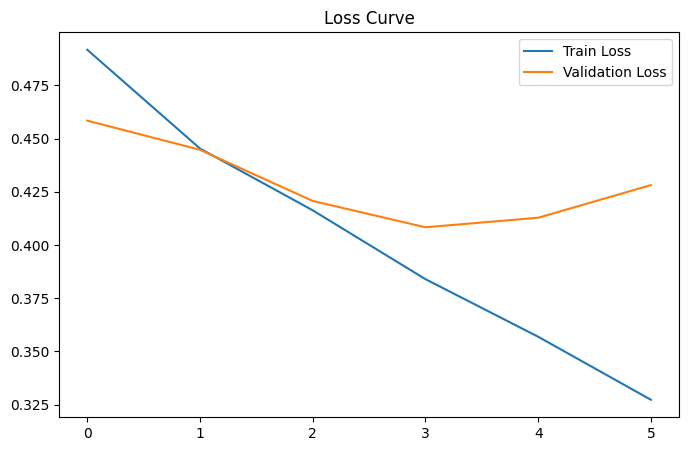

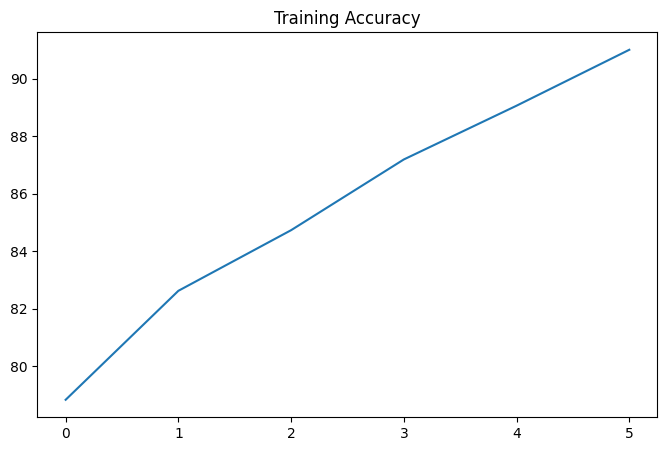

In [44]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.show()


Evaluation

C:\Users\monis\AppData\Local\Temp\ipykernel_86160\3163526665.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_binary_attention.pt")

              precision    recall  f1-score   support

           0       0.66      0.85      0.75      4578
           1       0.95      0.86      0.91     14856

    accuracy                           0.86     19434
   macro avg       0.81      0.86      0.83     19434
weighted avg       0.88      0.86      0.87     19434



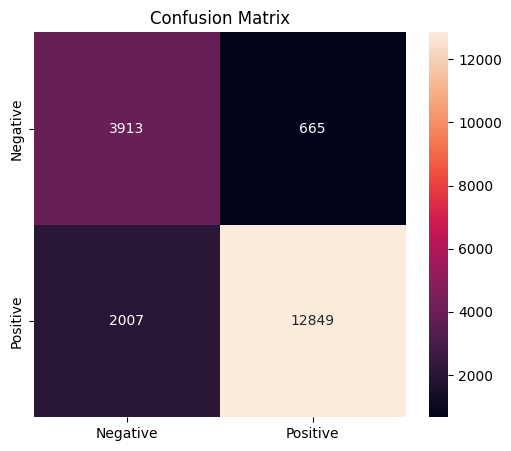

In [45]:
model.load_state_dict(torch.load("best_binary_attention.pt"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        pred = torch.argmax(out, dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])
plt.title("Confusion Matrix")
plt.show()
